# [STARTER] Udaplay Project

## Part 02 - Agent

In this part of the project, you'll use your VectorDB to be part of your Agent as a tool.

You're building UdaPlay, an AI Research Agent for the video game industry. The agent will:
1. Answer questions using internal knowledge (RAG)
2. Search the web when needed
3. Maintain conversation state
4. Return structured outputs
5. Store useful information for future use

### Setup

In [1]:
# Only needed for Udacity workspace

import importlib.util
import sys

# Check if 'pysqlite3' is available before importing
if importlib.util.find_spec("pysqlite3") is not None:
    import pysqlite3
    sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')

In [2]:
# Import the project dependencies
import json
import os

import chromadb
from chromadb.utils import embedding_functions
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from tavily import TavilyClient

from lib.agents import Agent
from lib.llm import LLM
from lib.messages import UserMessage, SystemMessage, ToolMessage, AIMessage
from lib.tooling import tool

In [3]:
# Load environment variables from starter/.env
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

print(f"OPENAI_API_KEY loaded: {bool(OPENAI_API_KEY)}")
print(f"TAVILY_API_KEY loaded: {bool(TAVILY_API_KEY)}")

OPENAI_API_KEY loaded: True
TAVILY_API_KEY loaded: True


In [10]:
retrieval_results = retrieve_game("When was Pokémon Gold and Silver released?")
print(f"Retrieved {len(retrieval_results)} documents")
print(retrieval_results[0] if retrieval_results else "No results")

Retrieved 3 documents
{'document': '[Game Boy Color] Pokémon Gold and Silver (1999) - Second-generation Pokémon games introducing new regions, Pokémon, and gameplay mechanics.', 'metadata': {'Name': 'Pokémon Gold and Silver', 'Description': 'Second-generation Pokémon games introducing new regions, Pokémon, and gameplay mechanics.', 'Genre': 'Role-playing', 'YearOfRelease': 1999, 'Platform': 'Game Boy Color', 'Publisher': 'Nintendo'}, 'distance': 0.11277824640274048}


### Tools

Build at least 3 tools:
- retrieve_game: To search the vector DB
- evaluate_retrieval: To assess the retrieval performance
- game_web_search: If no good, search the web


#### Retrieve Game Tool

In [7]:
# Connect to the persistent collection created in Part 1.
chroma_client = chromadb.PersistentClient(path="chromadb")
embedding_fn = embedding_functions.OpenAIEmbeddingFunction(
    api_key=OPENAI_API_KEY
)
collection = chroma_client.get_collection(
    name="udaplay",
    embedding_function=embedding_fn,
)

@tool
def retrieve_game(query: str) -> list[dict]:
    """Search the game knowledge base for games relevant to a question."""
    results = collection.query(
        query_texts=[query],
        n_results=3,
        include=["documents", "metadatas", "distances"],
    )
    documents = results.get("documents", [[]])[0]
    metadatas = results.get("metadatas", [[]])[0]
    distances = results.get("distances", [[]])[0]
    return [
        {
            "document": document,
            "metadata": metadata,
            "distance": distance,
        }
        for document, metadata, distance in zip(documents, metadatas, distances)
    ]

In [10]:
# Re-index any game JSON files that are not yet in the persistent collection.
indexed_ids = set(collection.get(include=["metadatas"]).get("ids", []))
new_ids = []
new_documents = []
new_metadatas = []

for file_name in sorted(os.listdir("games")):
    if not file_name.endswith(".json"):
        continue

    doc_id = os.path.splitext(file_name)[0]
    if doc_id in indexed_ids:
        continue

    with open(os.path.join("games", file_name), "r", encoding="utf-8") as file:
        game = json.load(file)

    new_ids.append(doc_id)
    new_documents.append(
        f"[{game['Platform']}] {game['Name']} ({game['YearOfRelease']}) - {game['Description']}"
    )
    new_metadatas.append(game)

if new_ids:
    collection.upsert(
        ids=new_ids,
        documents=new_documents,
        metadatas=new_metadatas,
    )

print(f"Re-indexed {len(new_ids)} new game records")
print(f"Knowledge base now contains {collection.count()} records")

Re-indexed 10 new game records
Knowledge base now contains 30 records


### Retrieval Dashboard

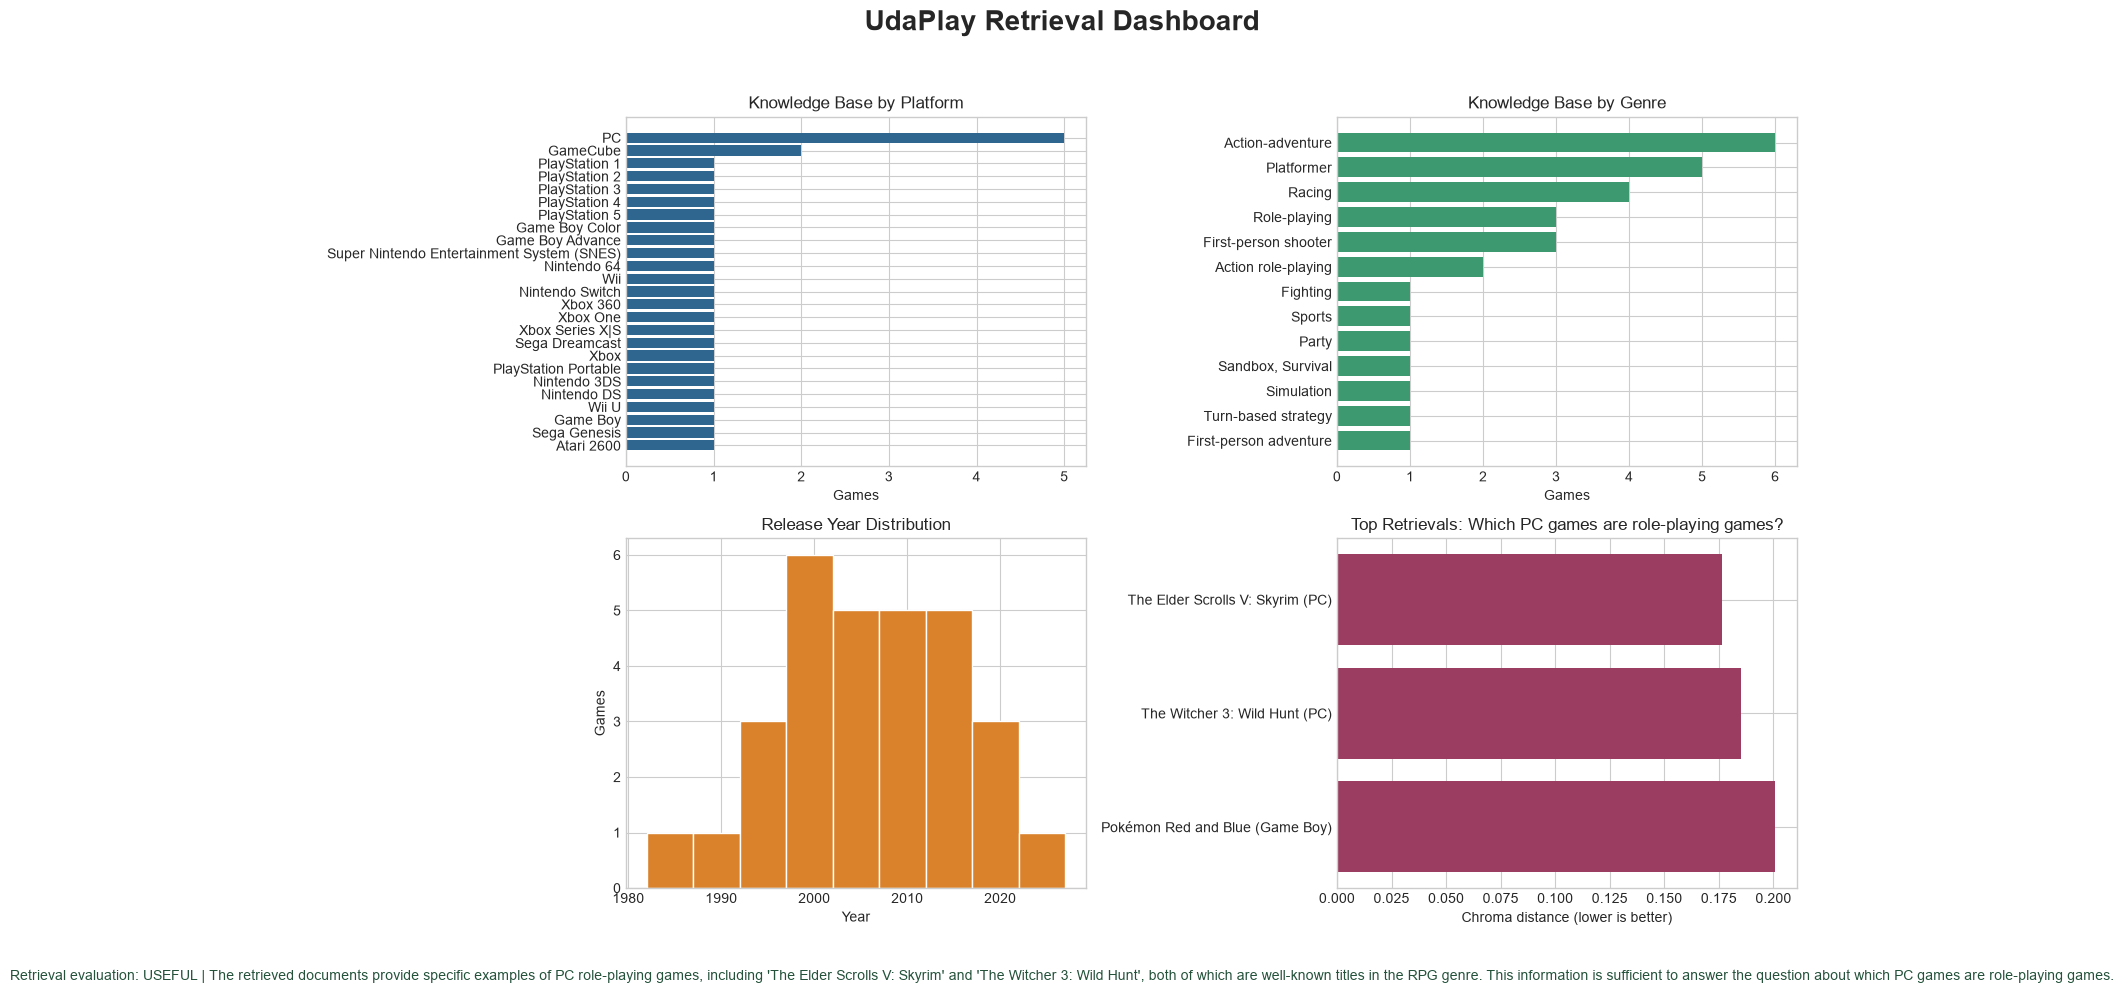

In [11]:
from collections import Counter
from datetime import datetime

import matplotlib.pyplot as plt


def show_retrieval_dashboard(query: str = "Which PC games are role-playing games?") -> None:
    """Visualize the knowledge base and the retrieval path for one query."""
    knowledge_base = collection.get(include=["metadatas", "documents"])
    metadata = knowledge_base.get("metadatas", [])
    records = [item for item in metadata if item]
    retrieved = retrieve_game(query)
    evaluation = evaluate_retrieval(query, retrieved)

    platforms = Counter(item["Platform"] for item in records)
    genres = Counter(item["Genre"] for item in records)
    years = sorted(item["YearOfRelease"] for item in records)

    plt.style.use("seaborn-v0_8-whitegrid")
    figure, axes = plt.subplots(2, 2, figsize=(15, 10))
    figure.suptitle("UdaPlay Retrieval Dashboard", fontsize=20, fontweight="bold")

    platform_names, platform_counts = zip(*platforms.most_common())
    axes[0, 0].barh(platform_names[::-1], platform_counts[::-1], color="#2f6690")
    axes[0, 0].set_title("Knowledge Base by Platform")
    axes[0, 0].set_xlabel("Games")

    genre_names, genre_counts = zip(*genres.most_common())
    axes[0, 1].barh(genre_names[::-1], genre_counts[::-1], color="#3d9970")
    axes[0, 1].set_title("Knowledge Base by Genre")
    axes[0, 1].set_xlabel("Games")

    axes[1, 0].hist(years, bins=range(min(years), max(years) + 6, 5), color="#d9822b", edgecolor="white")
    axes[1, 0].set_title("Release Year Distribution")
    axes[1, 0].set_xlabel("Year")
    axes[1, 0].set_ylabel("Games")

    labels = [
        f"{item['metadata'].get('Name', 'Unknown')} ({item['metadata'].get('Platform', 'Unknown')})"
        for item in retrieved
    ]
    distances = [item["distance"] for item in retrieved]
    axes[1, 1].barh(labels[::-1], distances[::-1], color="#9b3d61")
    axes[1, 1].set_title(f"Top Retrievals: {query}")
    axes[1, 1].set_xlabel("Chroma distance (lower is better)")

    status = "USEFUL" if evaluation["useful"] else "NEEDS WEB SEARCH"
    figure.text(
        0.5,
        0.01,
        f"Retrieval evaluation: {status} | {evaluation['description']}",
        ha="center",
        fontsize=10,
        color="#24523b" if evaluation["useful"] else "#8a2533",
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


show_retrieval_dashboard()

#### Evaluate Retrieval Tool

In [5]:
class EvaluationReport(BaseModel):
    useful: bool = Field(description="Whether the retrieved documents answer the question")
    description: str = Field(description="Why the documents are or are not sufficient")


evaluation_llm = LLM(model="gpt-4o-mini", temperature=0)

@tool
def evaluate_retrieval(
    question: str,
    retrieved_docs: list[dict],
) -> dict:
    """Assess whether retrieved game documents are sufficient to answer a question."""
    prompt = (
        "Evaluate whether the retrieved documents are sufficient to answer the question. "
        "Return useful=true only when the documents contain the facts needed for a reliable answer. "
        "Explain the decision briefly.\n\n"
        f"Question: {question}\n"
        f"Retrieved documents: {json.dumps(retrieved_docs, ensure_ascii=True)}"
    )
    response = evaluation_llm.invoke(prompt, response_format=EvaluationReport)
    return EvaluationReport.model_validate_json(response.content).model_dump()


#### Game Web Search Tool

In [12]:
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

@tool
def game_web_search(question: str) -> list[dict]:
    """Search the web for current or missing video game information."""
    response = tavily_client.search(
        query=question,
        search_depth="advanced",
        max_results=5,
    )
    return response.get("results", [])

#### Review Sentiment and Trending Games Tools

In [13]:
from typing import Literal


class ReviewSentiment(BaseModel):
    sentiment: Literal["positive", "negative", "mixed", "neutral"]
    score: float = Field(ge=-1, le=1, description="Overall sentiment from negative to positive")
    confidence: float = Field(ge=0, le=1)
    themes: list[str]
    summary: str


sentiment_llm = LLM(model="gpt-4o-mini", temperature=0)


@tool
def analyze_review_sentiment(review_text: str, game_title: str = "") -> dict:
    """Analyze a game review and return sentiment, themes, confidence, and a summary."""
    title_context = f" for {game_title}" if game_title else ""
    prompt = (
        "Analyze the following video game review" + title_context + ". "
        "Classify its overall sentiment, score it from -1 to 1, identify the main themes, "
        "and summarize the evidence. Do not infer facts that are not present in the review.\n\n"
        f"Review:\n{review_text}"
    )
    response = sentiment_llm.invoke(prompt, response_format=ReviewSentiment)
    return ReviewSentiment.model_validate_json(response.content).model_dump()


class TrendingGame(BaseModel):
    title: str
    trend_signal: str = Field(description="Recent evidence that this game is attracting attention")
    evidence: str
    source_urls: list[str]


class TrendingReport(BaseModel):
    timeframe: str
    games: list[TrendingGame]
    caveat: str


trending_llm = LLM(model="gpt-4o-mini", temperature=0)


@tool
def detect_trending_games(timeframe: str = "past month", platform: str = "all") -> dict:
    """Find games with recent attention using web evidence and return a ranked trend report."""
    search_query = f"video game trending popular news releases players {timeframe}"
    if platform.lower() != "all":
        search_query += f" {platform}"

    search_response = tavily_client.search(
        query=search_query,
        search_depth="advanced",
        max_results=8,
    )
    sources = [
        {
            "title": result.get("title", ""),
            "url": result.get("url", ""),
            "content": result.get("content", ""),
            "published_date": result.get("published_date", ""),
        }
        for result in search_response.get("results", [])
    ]
    prompt = (
        "Identify up to five video games showing recent attention from the supplied web results. "
        "Rank only games supported by the evidence. Do not treat a single generic listicle as proof "
        "of a trend. Include source URLs and state a caveat about search coverage.\n\n"
        f"Timeframe: {timeframe}\nPlatform filter: {platform}\n"
        f"Web results:\n{json.dumps(sources, ensure_ascii=True)}"
    )
    response = trending_llm.invoke(prompt, response_format=TrendingReport)
    return TrendingReport.model_validate_json(response.content).model_dump()


In [15]:
sentiment_demo = analyze_review_sentiment(
    "The combat feels excellent and the world is beautiful, but the menus are confusing and the story is predictable.",
    game_title="Demo Game",
)
trend_demo = detect_trending_games(timeframe="past month")
print("Sentiment demo:", sentiment_demo)
print("Trending games:", [game["title"] for game in trend_demo["games"]])
print("Trend caveat:", trend_demo["caveat"])

Sentiment demo: {'sentiment': 'mixed', 'score': 0.0, 'confidence': 0.85, 'themes': ['combat', 'graphics', 'user interface', 'storytelling'], 'summary': 'The review highlights positive aspects such as excellent combat and beautiful graphics, but also points out negative elements like confusing menus and a predictable story.'}
Trending games: ['Alan Wake 2', 'Grand Theft Auto VI', "Fire Emblem: Fortune's Weave", 'Subnautica 2', 'Roblox']
Trend caveat: The search results may not cover all trending games comprehensively, as they are limited to recent articles and may not reflect broader gaming trends.


### Agent

In [14]:
agent = Agent(
    model_name="gpt-4o-mini",
    temperature=0,
    instructions=(
        "You are UdaPlay, a careful video game research assistant. "
        "For game facts, call retrieve_game first. Then call evaluate_retrieval with the "
        "original question and retrieved documents. If the evaluation says the documents "
        "are not useful, call game_web_search. Use analyze_review_sentiment when the user "
        "provides a review to assess. Use detect_trending_games for requests about current "
        "or recent popularity, and clearly distinguish web evidence from verified sales data. "
        "Answer concisely and distinguish facts from uncertainty. Never invent release dates, "
        "platforms, sentiment evidence, or trend claims."
    ),
    tools=[
        retrieve_game,
        evaluate_retrieval,
        game_web_search,
        analyze_review_sentiment,
        detect_trending_games,
    ],
)

In [11]:
questions = [
    "When was Pokémon Gold and Silver released?",
    "Which one was the first 3D platformer Mario game?",
    "Was Mortal Kombat X released for PlayStation 5?",
]

for question in questions:
    run = agent.invoke(question)
    final_state = run.get_final_state()
    print(f"Question: {question}")
    print(f"Answer: {final_state['messages'][-1].content}")
    print(f"Tokens: {final_state.get('total_tokens', 0)}")
    print()

[StateMachine] Starting: __entry__
[StateMachine] Executing step: message_prep
[StateMachine] Executing step: llm_processor
[StateMachine] Executing step: tool_executor
[StateMachine] Executing step: llm_processor
[StateMachine] Executing step: tool_executor
[StateMachine] Executing step: llm_processor
[StateMachine] Terminating: __termination__
Question: When was Pokémon Gold and Silver released?
Answer: Pokémon Gold and Silver were released in 1999 for the Game Boy Color.
Tokens: 1614

[StateMachine] Starting: __entry__
[StateMachine] Executing step: message_prep
[StateMachine] Executing step: llm_processor
[StateMachine] Executing step: tool_executor
[StateMachine] Executing step: llm_processor
[StateMachine] Executing step: tool_executor
[StateMachine] Executing step: llm_processor
[StateMachine] Terminating: __termination__
Question: Which one was the first 3D platformer Mario game?
Answer: The first 3D platformer Mario game is **Super Mario 64**, released in 1996 for the Nintendo

### (Optional) Advanced

In [15]:
# Advanced: persistent long-term memory around the existing state-machine agent.
import importlib

import lib.memory as memory_module
import lib.vector_db as vector_db_module

importlib.reload(vector_db_module)
importlib.reload(memory_module)

from lib.memory import LongTermMemory, MemoryFragment
from lib.vector_db import VectorStoreManager

long_term_memory = LongTermMemory(
    VectorStoreManager(OPENAI_API_KEY, persist_path="chromadb")
)


def remember_interaction(question: str, answer: str, owner: str) -> None:
    long_term_memory.register(
        MemoryFragment(
            content=f"Question: {question}\nAnswer: {answer}",
            owner=owner,
            namespace="udaplay",
        )
    )


def recall_memories(question: str, owner: str, limit: int = 3) -> list[str]:
    result = long_term_memory.search(
        query_text=question,
        owner=owner,
        namespace="udaplay",
        limit=limit,
    )
    return [fragment.content for fragment in result.fragments]


def invoke_with_long_term_memory(
    question: str,
    session_id: str = "advanced",
):
    memories = recall_memories(question, owner=session_id)
    context = "\n\n".join(memories)
    enriched_question = question
    if context:
        enriched_question = (
            "Relevant remembered context:\n"
            f"{context}\n\nCurrent question: {question}"
        )

    run = agent.invoke(enriched_question, session_id=session_id)
    final_state = run.get_final_state()
    answer = final_state["messages"][-1].content
    remember_interaction(question, answer, owner=session_id)
    return run


remember_interaction(
    "The user prefers concise game research answers.",
    "Preference recorded.",
    owner="advanced-demo",
)
print("Recalled memory:", recall_memories("How should answers be written?", "advanced-demo"))
advanced_run = invoke_with_long_term_memory(
    "When was Pokémon Gold and Silver released?",
    session_id="advanced-demo",
)
print("Advanced answer:", advanced_run.get_final_state()["messages"][-1].content)

Recalled memory: ['Question: The user prefers concise game research answers.\nAnswer: Preference recorded.']
[StateMachine] Starting: __entry__
[StateMachine] Executing step: message_prep
[StateMachine] Executing step: llm_processor
[StateMachine] Executing step: tool_executor
[StateMachine] Executing step: llm_processor
[StateMachine] Executing step: tool_executor
[StateMachine] Executing step: llm_processor
[StateMachine] Executing step: tool_executor
[StateMachine] Executing step: llm_processor
[StateMachine] Terminating: __termination__
Advanced answer: **Pokémon Gold and Silver** were released on the following dates:
- **Japan**: November 21, 1999
- **North America**: October 15, 2000
- **Australia**: October 13, 2000
- **Europe**: April 6, 2001

These games were developed for the Game Boy Color and are part of the second generation of the Pokémon series.
